Homework 6 for Markov-4560. Aiden Rudd

1d. Completing 1d. This problem was asking us to assume starting in node 2.. an EVEN node. Then plot it and compare to the stationary distribution.

In [9]:
##
### Creation of both matrices.
##

import numpy as np

P = np.array([
    [0, 1, 0, 0, 0],
    [1/3, 0, 2/3, 0, 0],
    [0, 1/2, 0, 1/2, 0],
    [0, 0, 2/3, 0, 1/3],
    [0, 0, 0, 1, 0]
])

q0 = np.array([0, 0, 1, 0, 0])

# Compute q50
q50 = q0 @ np.linalg.matrix_power(P, 50)

# Stationary distribution
pi = np.array([1/12, 1/4, 1/3, 1/4, 1/12])


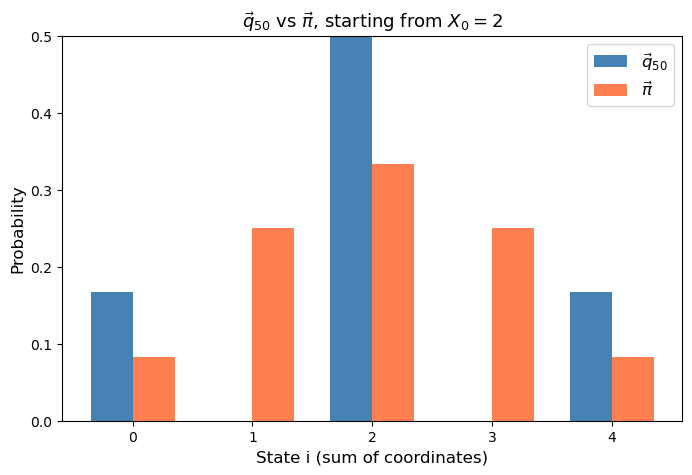

In [10]:
##
### Plotting each and comparison. 
##

import matplotlib.pyplot as plt

# Plot
states = [0, 1, 2, 3, 4]
x = np.arange(len(states))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, q50, width, label=r'$\vec{q}_{50}$', color='steelblue')
ax.bar(x + width/2, pi,  width, label=r'$\vec{\pi}$',    color='coral')

ax.set_xlabel('State i (sum of coordinates)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(r'$\vec{q}_{50}$ vs $\vec{\pi}$, starting from $X_0 = 2$', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(states)
ax.legend(fontsize=12)
ax.set_ylim(0, 0.5)

plt.savefig('HW6_problem1d.png', dpi=150)
plt.show()


This makes a lot of sense. Since the starting point is 2, which is even and 50 is also even, we will natually land again on an even number. This is due to the periodicity that was mentioned in part c. So naturally when we compare it to the stationary distribution we will see an increase to the probability it is on an even number, and not see it at all on the odd states. 

2

4b. We will now go over part b of problem 4. Recall, this is simulating 10^3 avalanches for a = 0.49 and estimate probability of extinction by calculating the function of avalanches that go extinct before 200 generations. Compare this to the value that we found in part a. 

In [3]:
import numpy as np

# params..
a = 0.49
n_avalanches = 1000
max_generations = 200

extinct_count = 0

for _ in range(n_avalanches):
    X = 1  # start with 1 particle
    
    for gen in range(max_generations):
        if X == 0:
            extinct_count += 1
            break
        # number that reproduce is Binomial(X, 1-a)
        Z = np.random.binomial(X, 1 - a)
        X = 2 * Z  # each reproducing particle makes 2
    
# Estimate extinction probability
p_extinct_empirical = extinct_count / n_avalanches
p_extinct_theory = a / (1 - a)

print(f"Empirical extinction probability: {p_extinct_empirical:.4f}")
print(f"Theoretical extinction probability: {p_extinct_theory:.4f}")

Empirical extinction probability: 0.9660
Theoretical extinction probability: 0.9608


Looking at these results, we can see that we are very close to our estimate using the found equation in part a. Both of which hover right around 96%. Note that the Empirical estimate is a tad bit higher. Intuitively, this also makes sense. We only ran 200 generations, so there may be some that are still alive that would die out later on. Running more avalanches would lead to a slight drop. We can see this below for fun. 

In [5]:
import numpy as np

# params..
a = 0.49
n_avalanches = 100000
max_generations = 200

extinct_count = 0

for _ in range(n_avalanches):
    X = 1  # start with 1 particle
    
    for gen in range(max_generations):
        if X == 0:
            extinct_count += 1
            break
        # number that reproduce is Binomial(X, 1-a)
        Z = np.random.binomial(X, 1 - a)
        X = 2 * Z  # each reproducing particle makes 2
    
# Estimate extinction probability
p_extinct_empirical = extinct_count / n_avalanches
p_extinct_theory = a / (1 - a)

print(f"Empirical extinction probability: {p_extinct_empirical:.4f}")
print(f"Theoretical extinction probability: {p_extinct_theory:.4f}")

Empirical extinction probability: 0.9596
Theoretical extinction probability: 0.9608


This is exactly what we were expecting, tighteing the results of our empirical model and the theoretical significantly. 